In [1]:
#importing all the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
import seaborn as sns
import xgboost as xgb
from imblearn.combine import SMOTEENN

In [2]:
#Read the dataset from the filepath
data = pd.read_csv(r"C:\Users\ushas\Documents\Customer_Churn.csv")
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
#Print the shape, number of instances and attributes of dataframe
print("Dataframe shape:", data.shape)
print("Number of instances = %d" %(data.shape[0]))
print("Number of attributes = %d" %(data.shape[1]))

Dataframe shape: (7043, 21)
Number of instances = 7043
Number of attributes = 21


In [4]:
# Display information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
#Checking for missing values
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# Number of unique values in each columns
data.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [7]:
# Calculate the percentage churn distribution
churn_counts = data['Churn'].value_counts()
total = len(data)
percentage_churn = (churn_counts / total) * 100
print(percentage_churn)


Churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64


In [8]:
# checking for duplicated rows in the DataFrame
data.duplicated().sum()

0

In [9]:
# convert TotalCharges to a numeric value
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data["TotalCharges"].dtype

dtype('float64')

In [10]:
#Checking for missing values after the conversion
data.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
#Check for missing values in the "TotalCharges" column
data[np.isnan(data["TotalCharges"])]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [12]:
#Filling missing values with median values
data.loc[:, "TotalCharges"] = data["TotalCharges"].fillna(data["TotalCharges"].median())
print("Number of instances = %d" %(data.shape[0]))

Number of instances = 7043


In [13]:
#Convert senior citizen into objective type
data["SeniorCitizen"] = data["SeniorCitizen"].replace(1,"Yes")
data["SeniorCitizen"] = data["SeniorCitizen"].replace(0,"No")
data["SeniorCitizen"].unique()

array(['No', 'Yes'], dtype=object)

In [14]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [15]:
#Printing unique values for each column in the dataset
for column in data.columns:
    print(column, data[column].unique())

customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender ['Female' 'Male']
SeniorCitizen ['No' 'Yes']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit 

In [16]:
#discribe the numerical data
data.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928
std,24.559481,30.090047,2265.270398
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [17]:
#Drop Customer ID column
data.drop("customerID",axis="columns",inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


# Exploratory Data Analysis

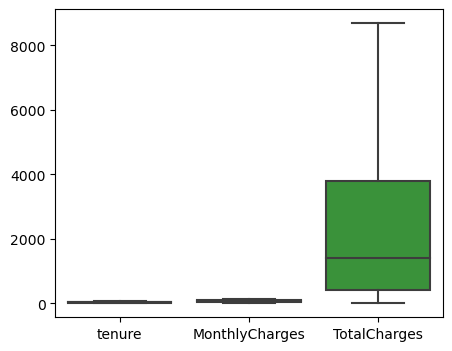

In [21]:
#visualizing the data to find the outliers
plt.figure(figsize=(5,4))
sns.boxplot(data)
plt.show()

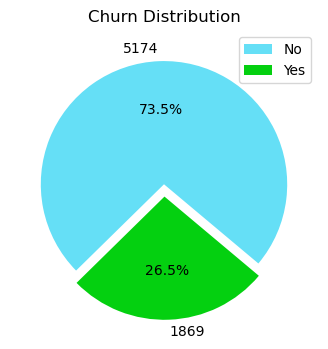

In [22]:
#Visualization of churn distribution using a pie chart
churn_counts = data['Churn'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(churn_counts, autopct='%1.1f%%',explode=[0,0.1], startangle=320, colors=['#65DFF6', '#04D010'], labels = churn_counts.values)
plt.title('Churn Distribution')
plt.legend(churn_counts.index)
plt.show()

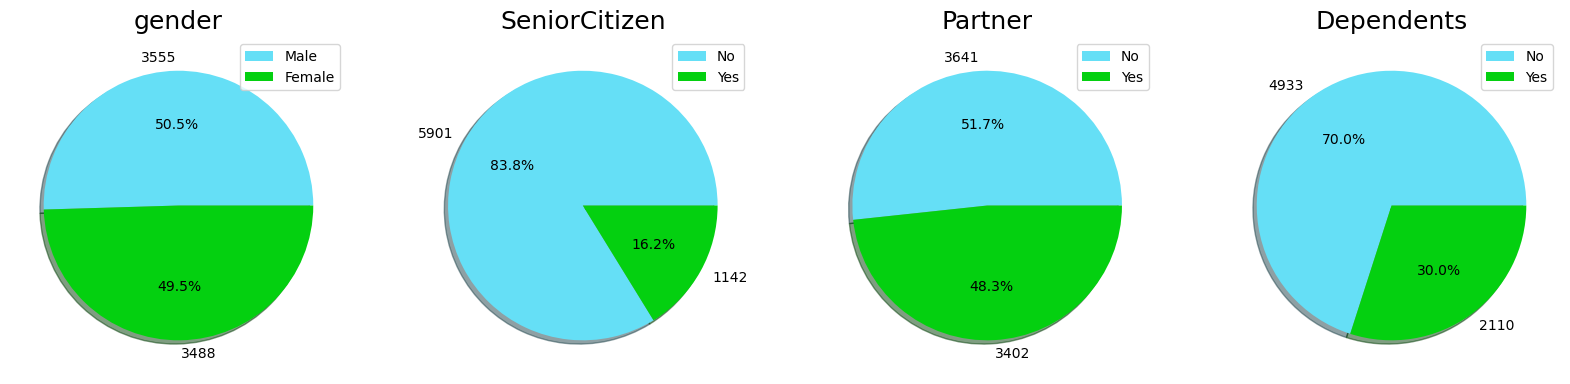

In [23]:
#creating pie charts for categorical columns 1-4
categ_columns = list(data.select_dtypes(include = ['object']).columns)
# Create subplots
fig, axes = plt.subplots(1, 4, figsize=(20, 12))
# Iterate over categorical columns and create pie charts
for i, column in enumerate(categ_columns[:4]):
    ax = axes[i]
    d = data[column].value_counts()
    ax.pie(d, labels=d.values,autopct="%1.1f%%",shadow=True, colors=['#65DFF6', '#04D010'])
    ax.set_title(column,size=18)
    ax.legend(d.index)

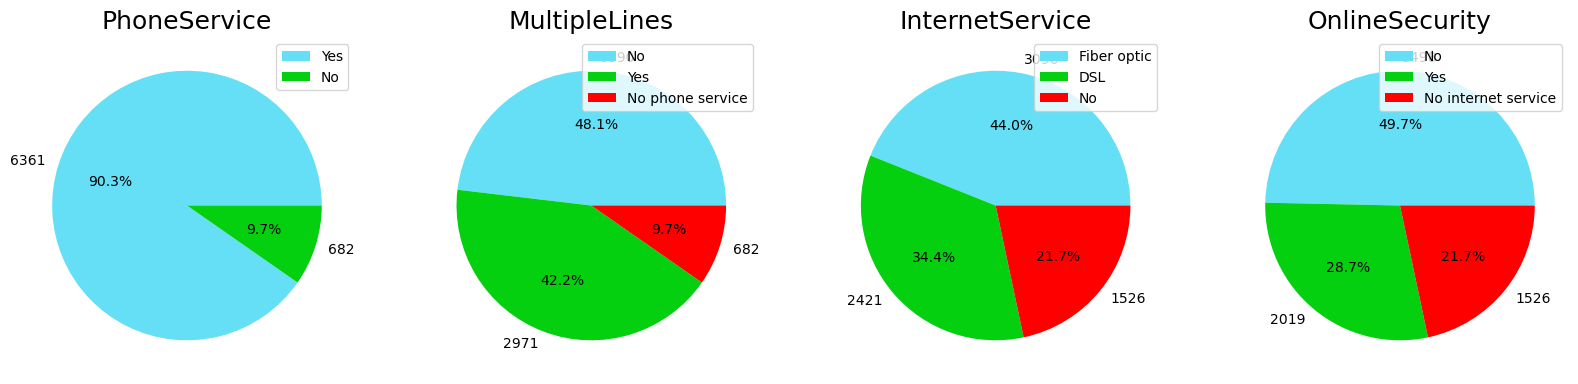

In [24]:
#creating pie charts for categorical columns 5-8
fig, axes = plt.subplots(1, 4, figsize=(20, 12))


for i, column in enumerate(categ_columns[4:8]):
    ax = axes[i]
    d = data[column].value_counts()
    ax.pie(d, labels=d.values,autopct="%1.1f%%", colors=['#65DFF6', '#04D010', 'red'])
    ax.set_title(column,size=18)
    ax.legend(d.index,loc="best")

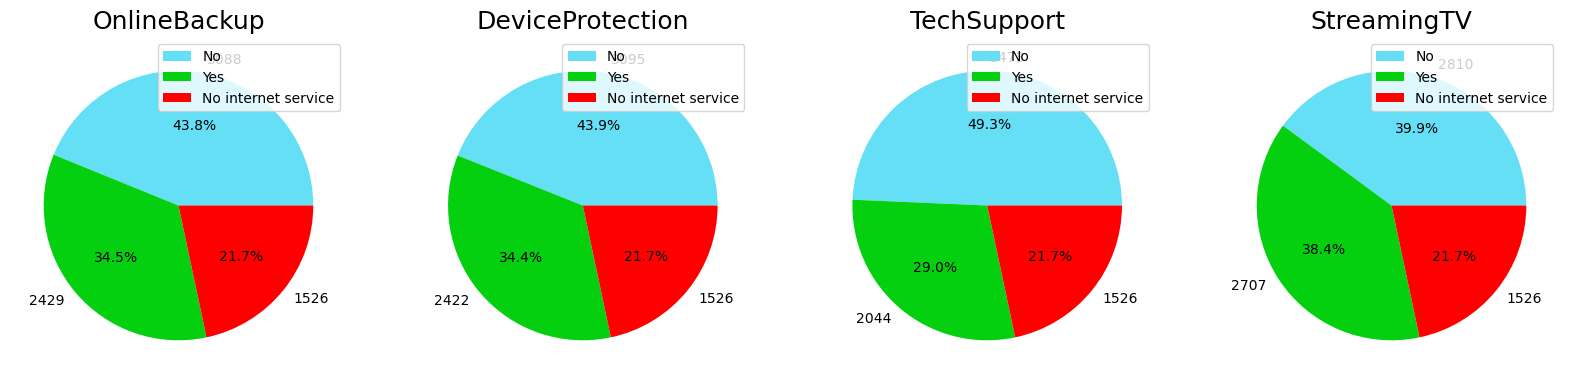

In [25]:
#creating pie charts for categorical columns 9-12
fig, axes = plt.subplots(1, 4, figsize=(20, 12))

for i, column in enumerate(categ_columns[8:12]):
    ax = axes[i]
    d = data[column].value_counts()
    ax.pie(d, labels=d.values,autopct="%1.1f%%", colors=['#65DFF6', '#04D010', 'red'])
    ax.set_title(column,size=18)
    ax.legend(d.index)

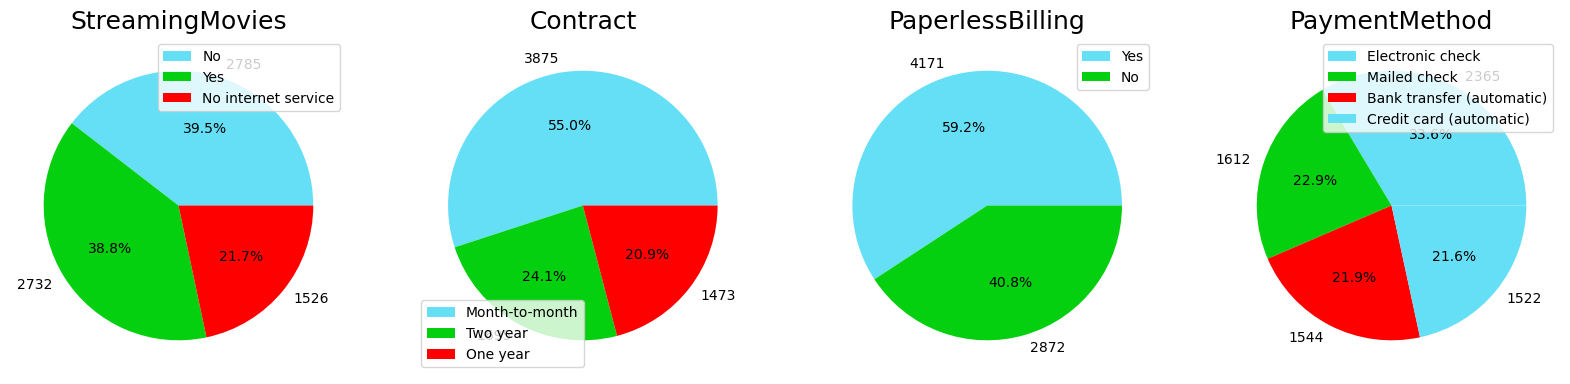

In [26]:
#creating pie charts for categorical columns 13-16
fig, axes = plt.subplots(1, 4, figsize=(20, 12))

for i, column in enumerate(categ_columns[12:16]):

        ax = axes[i]
        d = data[column].value_counts()
        ax.pie(d, labels=d.values,autopct="%1.1f%%", colors=['#65DFF6', '#04D010', 'red'])
        ax.set_title(column,size=18)
        ax.legend(d.index)

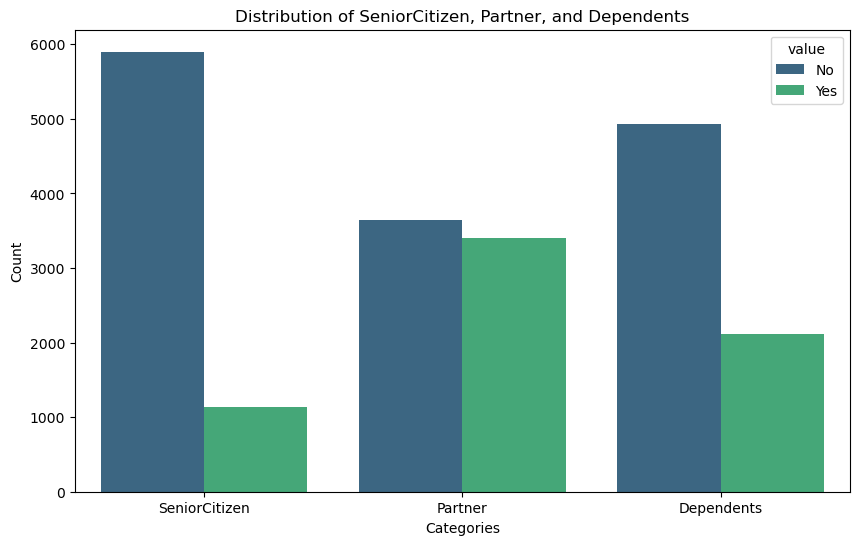

In [30]:
#Select specific columns
selected_columns = ['SeniorCitizen', 'Partner', 'Dependents']
selected_data = data[selected_columns]

# Melt the DataFrame to create a tidy format
melted_data = selected_data.melt()

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.countplot(data=melted_data, x='variable', hue='value', palette='viridis')
plt.title('Distribution of SeniorCitizen, Partner, and Dependents')
plt.xlabel('Categories')
plt.ylabel('Count')
plt.show()


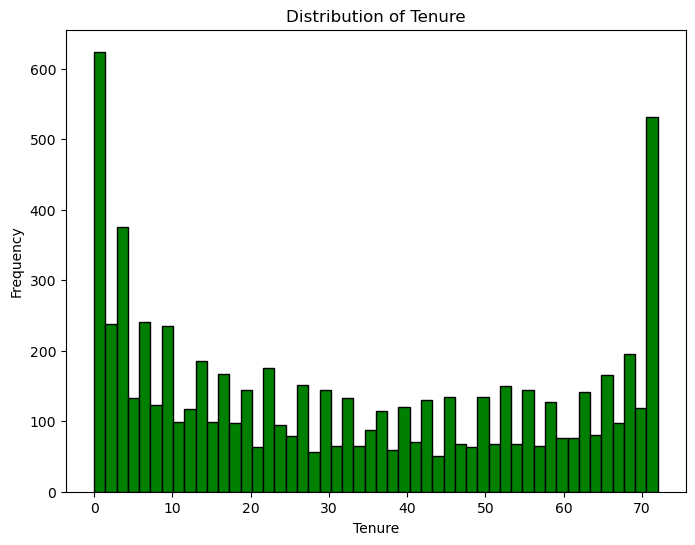

In [31]:
# Distribution of tenture data
plt.figure(figsize=(8, 6))
plt.hist(data['tenure'], bins=50, color='green', edgecolor='black')
plt.title('Distribution of Tenure')
plt.xlabel('Tenure')
plt.ylabel('Frequency')

plt.show()

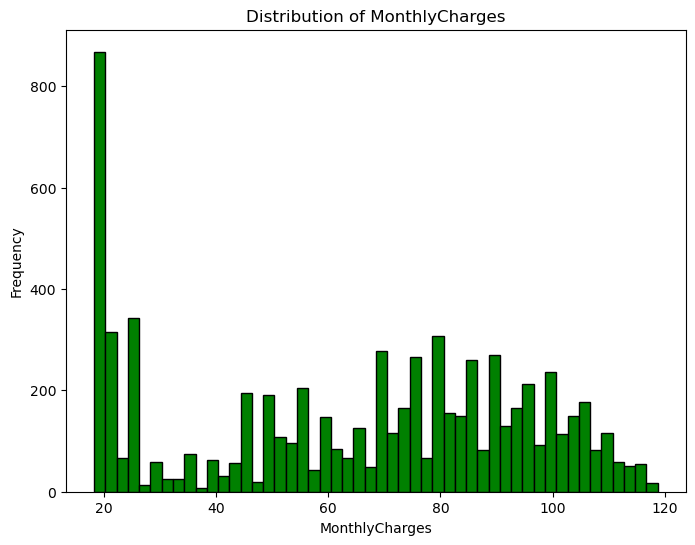

In [32]:
# Distribution of monthly charges data
plt.figure(figsize=(8, 6))
plt.hist(data['MonthlyCharges'], bins=50, color='green', edgecolor='black')
plt.title('Distribution of MonthlyCharges')
plt.xlabel('MonthlyCharges')
plt.ylabel('Frequency')
plt.show()

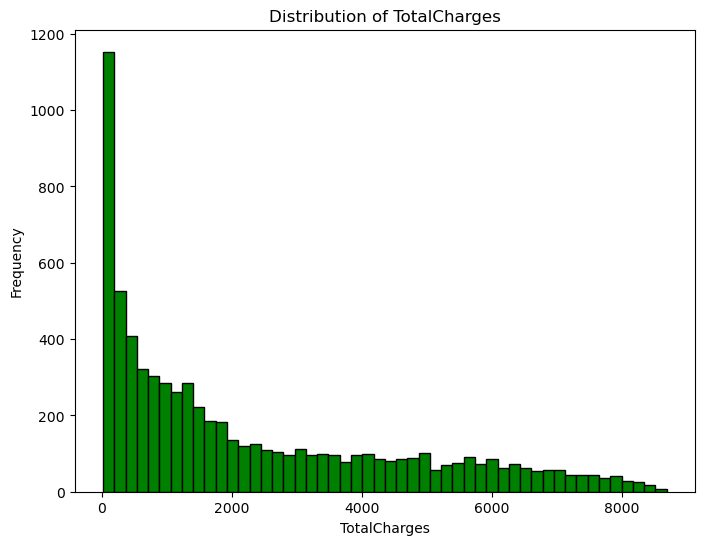

In [33]:
# Distribution of totalcharges data
plt.figure(figsize=(8, 6))
plt.hist(data['TotalCharges'], bins=50, color='green', edgecolor='black')
plt.title('Distribution of TotalCharges')
plt.xlabel('TotalCharges')
plt.ylabel('Frequency')
plt.show()

<Axes: xlabel='gender', ylabel='Count'>

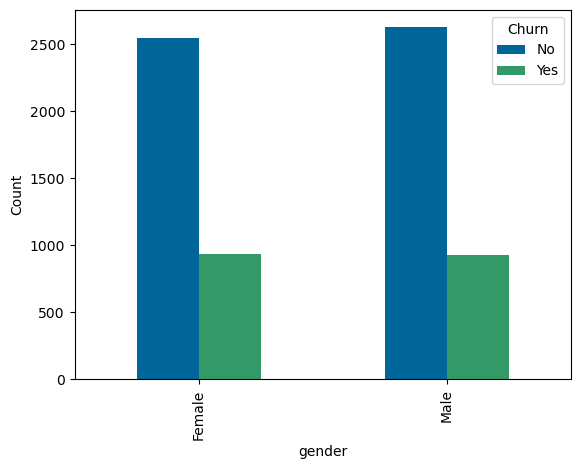

In [29]:
#ploting barplot for churn distribution among gender
pd.crosstab(data["gender"],data["Churn"]).plot(kind="bar",color=["#006699","#339966"], ylabel="Count")

<Axes: xlabel='PaymentMethod', ylabel='Count'>

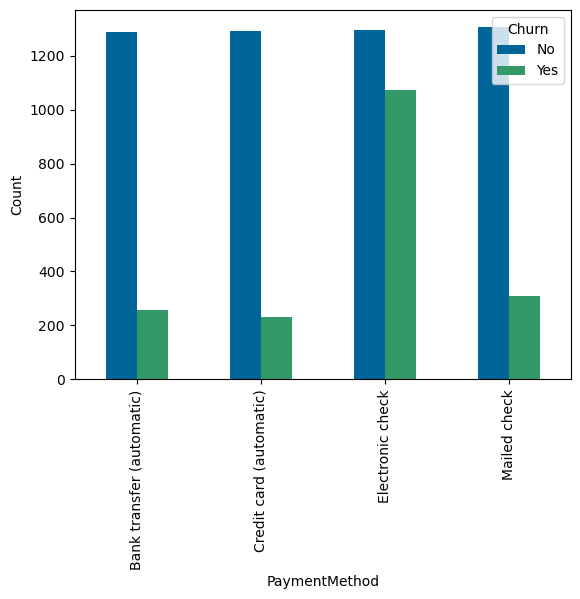

In [34]:
#ploting barplot for churn distribution among Payment methods
pd.crosstab(data["PaymentMethod"],data["Churn"]).plot(kind="bar",color=["#006699","#339966"], ylabel="Count")

<Axes: xlabel='Contract', ylabel='Count'>

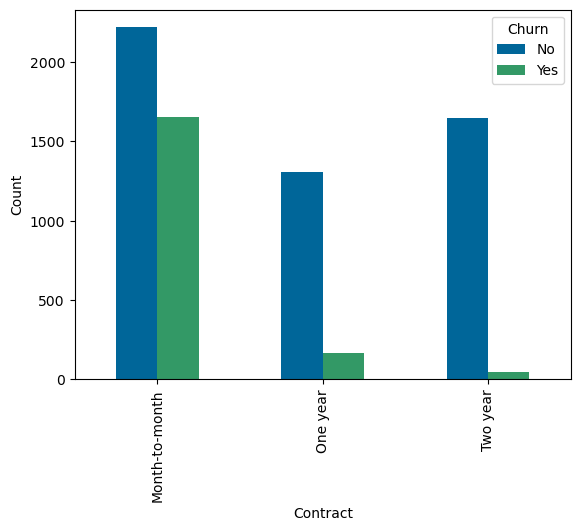

In [35]:
#ploting barplot for churn distribution among Contract
pd.crosstab(data["Contract"], data["Churn"]).plot(kind="bar", color=["#006699","#339966"], ylabel="Count")

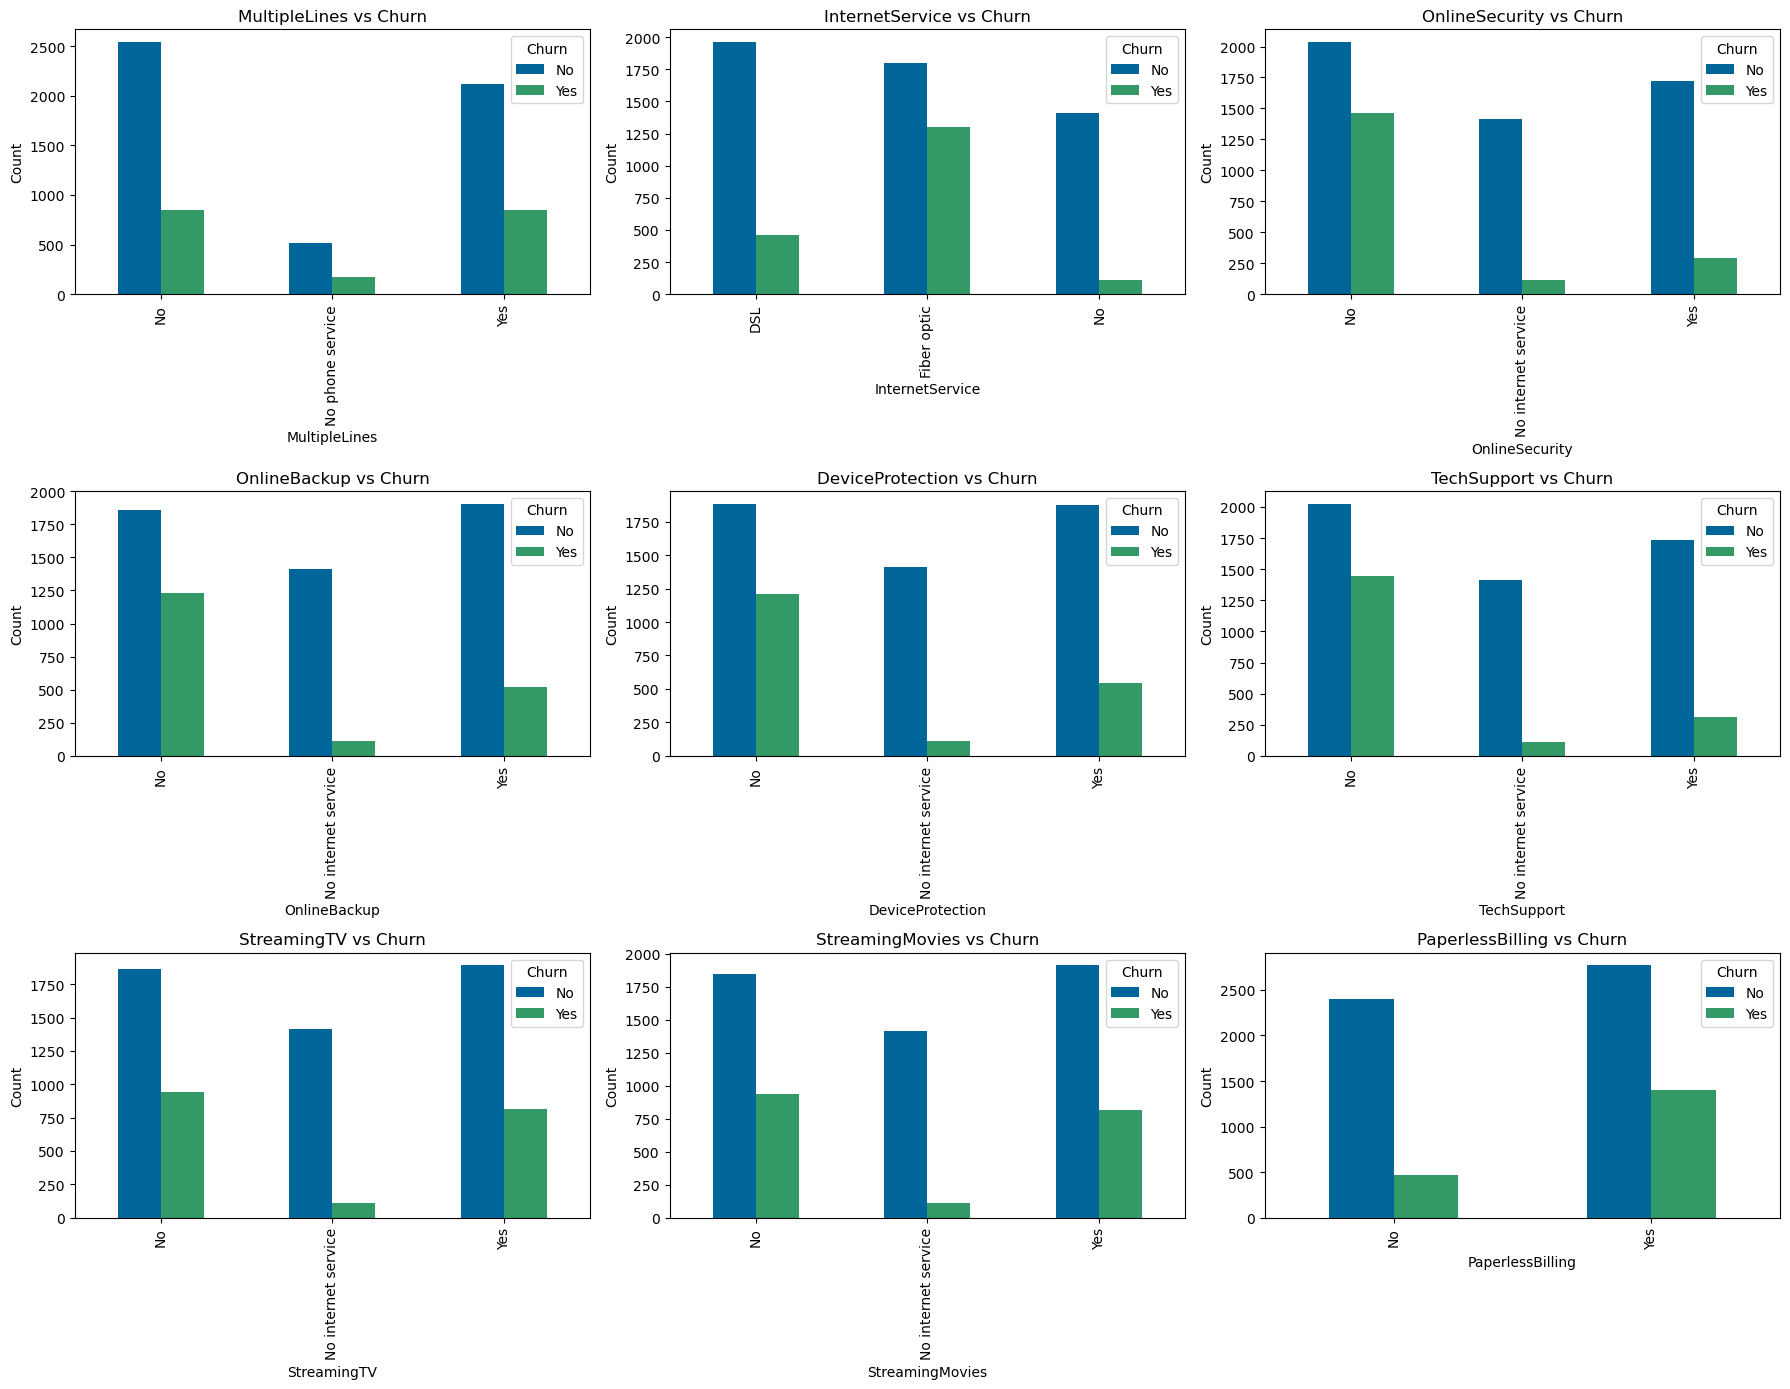

In [43]:
#Displaying churn distribution among all other attributs as subplot
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 14))

pd.crosstab(data["MultipleLines"], data["Churn"]).plot(kind="bar", color=["#006699", "#339966"], ax=axes[0, 0], ylabel="Count", title="MultipleLines vs Churn")
pd.crosstab(data["InternetService"], data["Churn"]).plot(kind="bar", color=["#006699", "#339966"], ax=axes[0, 1], ylabel="Count", title="InternetService vs Churn")
pd.crosstab(data["OnlineSecurity"], data["Churn"]).plot(kind="bar", color=["#006699", "#339966"], ax=axes[0, 2], ylabel="Count", title="OnlineSecurity vs Churn")

pd.crosstab(data["OnlineBackup"], data["Churn"]).plot(kind="bar", color=["#006699", "#339966"], ax=axes[1, 0], ylabel="Count", title="OnlineBackup vs Churn")
pd.crosstab(data["DeviceProtection"], data["Churn"]).plot(kind="bar", color=["#006699", "#339966"], ax=axes[1, 1], ylabel="Count", title="DeviceProtection vs Churn")
pd.crosstab(data["TechSupport"], data["Churn"]).plot(kind="bar", color=["#006699", "#339966"], ax=axes[1, 2], ylabel="Count", title="TechSupport vs Churn")

pd.crosstab(data["StreamingTV"], data["Churn"]).plot(kind="bar", color=["#006699", "#339966"], ax=axes[2, 0], ylabel="Count", title="StreamingTV vs Churn")
pd.crosstab(data["StreamingMovies"], data["Churn"]).plot(kind="bar", color=["#006699", "#339966"], ax=axes[2, 1], ylabel="Count", title="StreamingMovies vs Churn")
pd.crosstab(data["PaperlessBilling"], data["Churn"]).plot(kind="bar", color=["#006699", "#339966"], ax=axes[2, 2], ylabel="Count", title="PaperlessBilling vs Churn")

plt.tight_layout()
plt.show()



In [44]:
#selecting attributes of object type
df = data.select_dtypes(include=[object])
df.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,No,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,No,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,Male,No,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,Male,No,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,Female,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes


In [45]:
#transforming all oject data into numeric using onehot encoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')
df_trans = encoder.fit_transform(data[df.columns])
df_trans.head()

,gender_Female,gender_Male,SeniorCitizen_No,SeniorCitizen_Yes,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_No,Churn_Yes
0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


In [46]:
#adding the converted data into orginal dataset
data =  pd.concat([data, df_trans], axis=1)
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_No,Churn_Yes
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


In [47]:
#displaying dataset information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 65 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   object 
 1   SeniorCitizen                            7043 non-null   object 
 2   Partner                                  7043 non-null   object 
 3   Dependents                               7043 non-null   object 
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   object 
 6   MultipleLines                            7043 non-null   object 
 7   InternetService                          7043 non-null   object 
 8   OnlineSecurity                           7043 non-null   object 
 9   OnlineBackup                             7043 non-null   object 
 10  DeviceProtection                         7043 no

In [48]:
#droping unnecessory object type columns 
for i in df:
    data.drop([i], axis=1, inplace=True)
    
# Drop the 'Churn_No' column and rename 'Churn_Yes' to 'Churn'
data.drop('Churn_No', axis=1, inplace=True)
data.rename(columns={'Churn_Yes':'Churn'}, inplace=True)
data

,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,SeniorCitizen_No,SeniorCitizen_Yes,Partner_No,Partner_Yes,Dependents_No,...,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,1,29.85,29.85,1.0,0.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,34,56.95,1889.50,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2,53.85,108.15,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
3,45,42.30,1840.75,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,2,70.70,151.65,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,24,84.80,1990.50,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
7039,72,103.20,7362.90,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
7040,11,29.60,346.45,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
7041,4,74.40,306.60,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


In [49]:
#assigning features and target variable into x & y
x = data.drop('Churn', axis=1)
y = data['Churn'] 

In [50]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [51]:
#Scale the features in the training & test data using standerd scaler function
sc=StandardScaler()

x_train = sc.fit_transform(X_train)
x_test = sc.transform(X_test)

In [52]:
def churn_predict(method, x_Train, y_Train, x_Test, y_Test):
    
    # Fit the classifier to the training data
    method.fit(x_Train, y_Train)

    # compute predictions for training data
    prediction = method.predict(x_Test)
   
    # compute accuracy for training and testing data
    accuracy = accuracy_score(y_Test, prediction)
   
    # compute classification report for training and testing data
    classification_rep = classification_report(y_Test, prediction)
    
    # Compute the confusion matrix
    dt_conf_matrix = confusion_matrix(y_Test, prediction)
    
    # Print accuracy and classification report for training data
    print("Accuracy:", accuracy)
    print("Classification Report:")
    print(classification_rep)
    

    #Display confusion matrix
    plt.figure(figsize=(5, 3))
    sns.heatmap(dt_conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    

# Decision Tree

Accuracy: 0.7260468417317246
Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.81      0.81      1036
         1.0       0.48      0.49      0.49       373

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



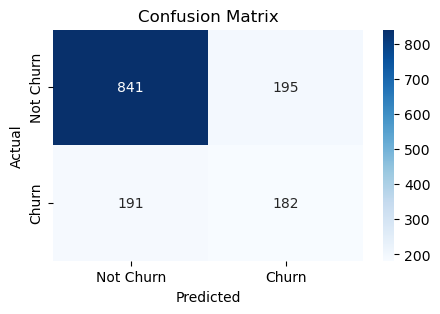

In [53]:
# Initialize the decision tree classifier
decision_tree = DecisionTreeClassifier()
churn_predict(decision_tree,x_train, y_train, x_test, y_test)

Accuracy: 0.8062455642299503
Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1036
         1.0       0.67      0.54      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



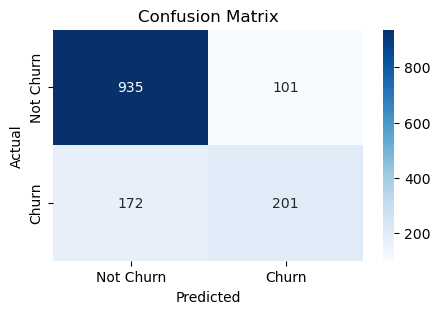

In [54]:
# obtimized decision tree classifier
decision_tree_model = DecisionTreeClassifier(criterion = "gini",random_state = 42,max_depth=6, min_samples_leaf=8)
churn_predict(decision_tree_model,x_train, y_train, x_test, y_test)

# Random Forest

Accuracy: 0.7955997161107168
Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.91      0.87      1036
         1.0       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



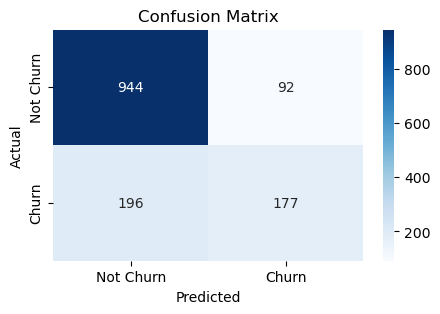

In [55]:
# Initialize the Random Forest classifier
random_forest_model = RandomForestClassifier()
churn_predict(random_forest_model,x_train, y_train, x_test, y_test)

# Grid Serach for Random Forest

In [56]:
# Assuming data is your dataset, where the last column represents the target variable
x = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Define the hyperparameters grid for grid search
param_grid = {
    'criterion' : ["gini", "entropy", "log_loss"],
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(estimator=random_forest_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the grid search to the data
grid_search.fit(x, y)

# Get the best parameters and the best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits
Best Parameters: {'bootstrap': True, 'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.8054816036518485


Accuracy: 0.8119233498935415
Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.91      0.88      1036
         1.0       0.69      0.53      0.60       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



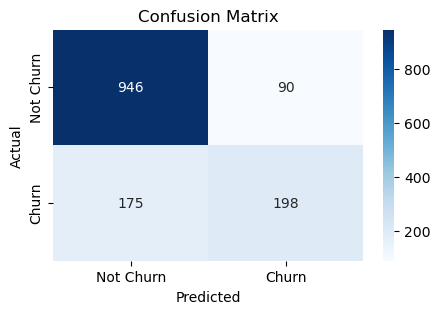

In [57]:
# Define the Random Forest classifier with the best parameters obtained from grid search
best_rf_classifier = RandomForestClassifier(criterion='gini', n_estimators=100, max_depth=10, min_samples_split=2, min_samples_leaf=4, bootstrap=True)
churn_predict(best_rf_classifier,x_train, y_train, x_test, y_test)

# Support Vector Machine

Accuracy: 0.8112136266855926
Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.92      0.88      1036
         1.0       0.69      0.52      0.59       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



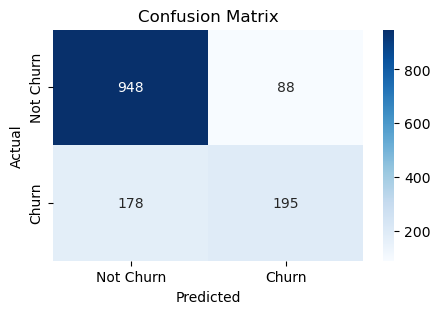

In [58]:
# Initialize the SVM classifier
svm_model = SVC()
churn_predict(svm_model,x_train, y_train, x_test, y_test)

# Grid Serach for SVM

In [59]:
# Define the hyperparameters grid for grid search
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4],
    'coef0': [0.0, 0.1, 0.5]
}

#perform grid search and fit the grid search to the data
grid_search = GridSearchCV(estimator=svm_model, param_grid=svm_param_grid, cv=5, verbose=2, n_jobs=-1)
grid_search.fit(x_train, y_train)

# Get the best parameters & accuracy
print("Best Parameters:", grid_search.best_params_)
test_score = grid_search.score(x_test, y_test)
print("Test set score:", test_score)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best Parameters: {'C': 1, 'coef0': 0.1, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}
Test set score: 0.8140525195173882


Accuracy: 0.8211497515968772
Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.90      0.88      1036
         1.0       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



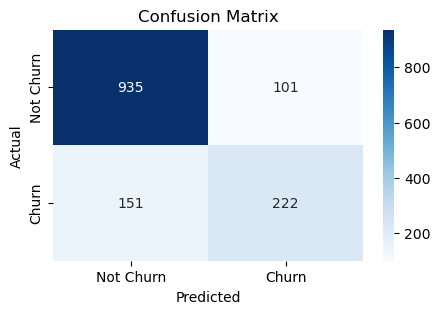

In [60]:
#Define the svm with the best parameters
best_svm_classifier =SVC(C=1, coef0=0.1, degree=2, gamma='scale', kernel='linear')
churn_predict(best_svm_classifier,x_train, y_train, x_test, y_test)

# SVM with Ada Boost

Accuracy: 0.7650816181689141
Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.77      0.83      1036
         1.0       0.54      0.74      0.63       373

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



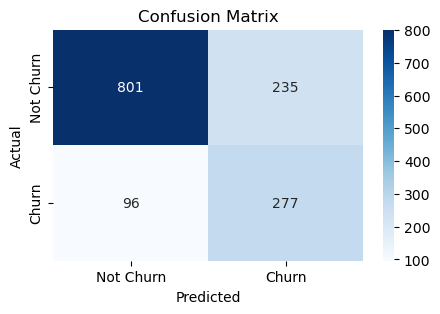

In [61]:
# Create an AdaBoost classifier with SVM as the base estimator
adaboost_classifier = AdaBoostClassifier(estimator=best_svm_classifier, n_estimators=50, algorithm='SAMME')
churn_predict(adaboost_classifier,x_train, y_train, x_test, y_test)

# XG Boost

Accuracy: 0.7934705464868701
Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.86      1036
         1.0       0.64      0.51      0.57       373

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



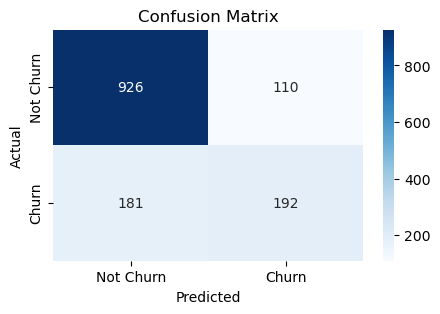

In [62]:
# Create an XGBoost classifier
xgb_classifier = xgb.XGBClassifier()
churn_predict(xgb_classifier,x_train, y_train, x_test, y_test)

# Grid Serach for XGBoost

In [63]:
# Define the grid of hyperparameters to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_child_weight': [1, 2, 3],
    'gamma': [0, 0.1, 0.2]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=xgb_classifier, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='accuracy')

# Fit the GridSearchCV object to the data
grid_search.fit(x_train, y_train)

# Best parameters & accuracy after Grid Search
best_params = grid_search.best_params_
print(f"Best parameters: {best_params}")
test_score = grid_search.score(x_test, y_test)
print("Best accuracy:", test_score)

Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best parameters: {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 50}
Best accuracy: 0.8140525195173882


Accuracy: 0.7934705464868701
Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.86      1036
         1.0       0.64      0.51      0.57       373

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



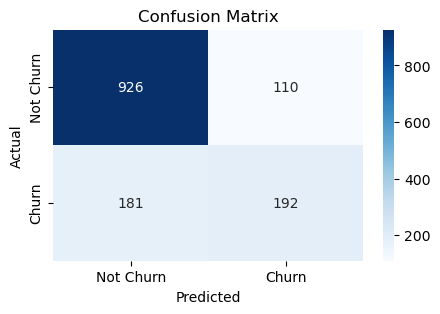

In [64]:
#Define the XGBooster with best parameters
best_xgb_classifier = xgb.XGBClassifier(gamma= 0, learning_rate= 0.1, max_depth= 4, min_child_weight= 3, n_estimators= 50)
churn_predict(xgb_classifier,x_train, y_train, x_test, y_test)

# Model Comparison 

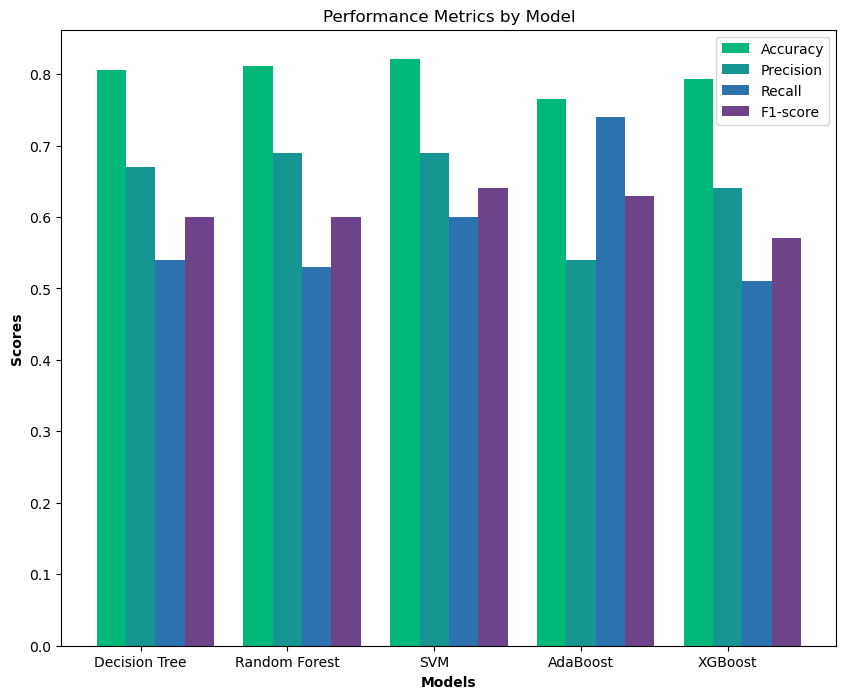

In [77]:
# Define the model names
models = ['Decision Tree', 'Random Forest', 'SVM','AdaBoost','XGBoost']

# Define the accuracy scores
accuracy_scores = [0.806, 0.811, 0.821, 0.765, 0.793]

# Define the precision scores
precision_scores = [0.67, 0.69, 0.69, 0.54, 0.64]

# Define the recall scores
recall_scores = [0.54, 0.53, 0.60, 0.74, 0.51]

# Define the F1 scores
f1_scores = [0.60, 0.60, 0.64, 0.63, 0.57]

# Set the bar width
bar_width = 0.2

# Set the positions of the bars on the x-axis
r1 = np.arange(len(accuracy_scores))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]
r4 = [x + bar_width for x in r3]
r5 = [x + bar_width for x in r4]

# Create the bar plot
plt.figure(figsize=(10, 8))
plt.bar(r1, accuracy_scores, color='#00B877', width=bar_width, label='Accuracy')
plt.bar(r2, precision_scores, color='#169593', width=bar_width, label='Precision')
plt.bar(r3, recall_scores, color='#2C72AF', width=bar_width, label='Recall')
plt.bar(r4, f1_scores, color='#6D4389', width=bar_width, label='F1-score')

# Add some text for labels, title, and axes ticks
plt.xlabel('Models', fontweight='bold')
plt.ylabel('Scores', fontweight='bold')
plt.title('Performance Metrics by Model')
plt.xticks([r + bar_width for r in range(len(accuracy_scores))], models)
plt.legend()

# Show the plot
plt.show()


#                                             SMOTE

In [70]:
#define SMOTEEN
sm = SMOTEENN()

#Resample the data using SMOTEENN
x_res, y_res = sm.fit_resample(x, y)
# Split the resampled data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x_res, y_res, test_size=0.2)

Accuracy: 0.928388746803069
Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.89      0.92       543
         1.0       0.91      0.96      0.94       630

    accuracy                           0.93      1173
   macro avg       0.93      0.93      0.93      1173
weighted avg       0.93      0.93      0.93      1173



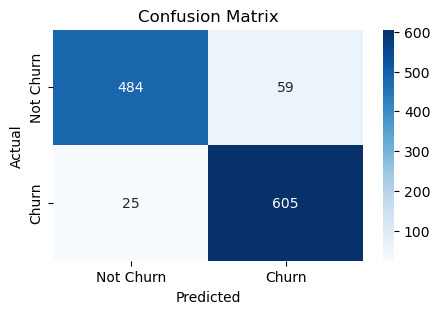

In [71]:
#Decision Tree Model after applying SMOTE
churn_predict(decision_tree_model,x_train, y_train, x_test, y_test)

Accuracy: 0.9548167092924126
Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.94      0.95       543
         1.0       0.95      0.97      0.96       630

    accuracy                           0.95      1173
   macro avg       0.96      0.95      0.95      1173
weighted avg       0.95      0.95      0.95      1173



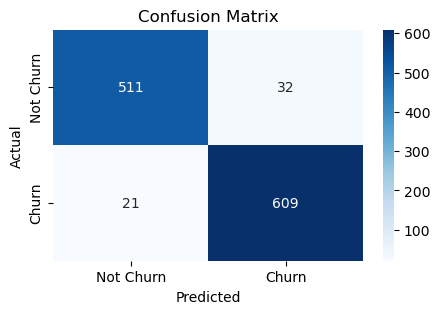

In [72]:
#Random Forest after applying SMOTE
churn_predict(random_forest_model,x_train, y_train, x_test, y_test)

Accuracy: 0.9173060528559249
Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.89      0.91       543
         1.0       0.91      0.94      0.92       630

    accuracy                           0.92      1173
   macro avg       0.92      0.92      0.92      1173
weighted avg       0.92      0.92      0.92      1173



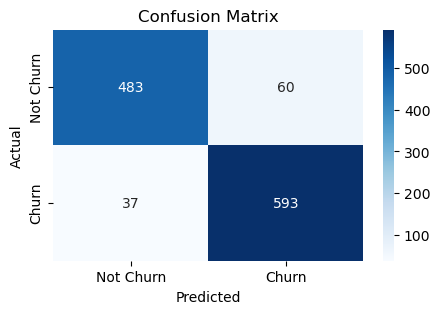

In [74]:
# SVM after applying SMOTE
churn_predict(best_svm_classifier,x_train, y_train, x_test, y_test)

Accuracy: 0.9062233589087809
Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.87      0.90       543
         1.0       0.90      0.93      0.91       630

    accuracy                           0.91      1173
   macro avg       0.91      0.90      0.91      1173
weighted avg       0.91      0.91      0.91      1173



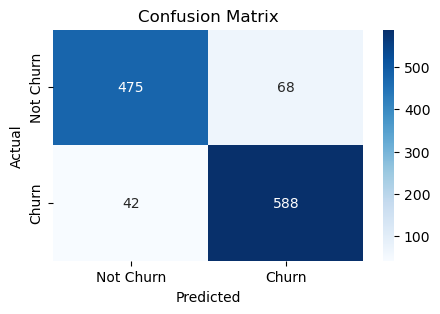

In [75]:
#AdaBoost with SVM after applying SMOTE
churn_predict(adaboost_classifier,x_train, y_train, x_test, y_test)

Accuracy: 0.9565217391304348
Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.95      0.95       543
         1.0       0.95      0.97      0.96       630

    accuracy                           0.96      1173
   macro avg       0.96      0.96      0.96      1173
weighted avg       0.96      0.96      0.96      1173



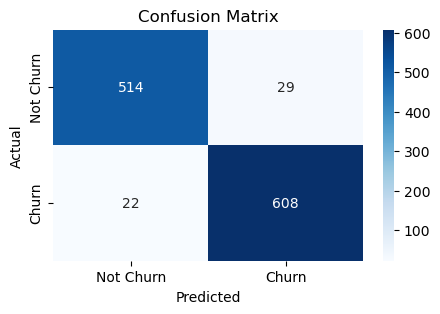

In [73]:
#XGBoost after applying SMOTE
churn_predict(xgb_classifier,x_train, y_train, x_test, y_test)

# Model Comparison After Applying SMOTE

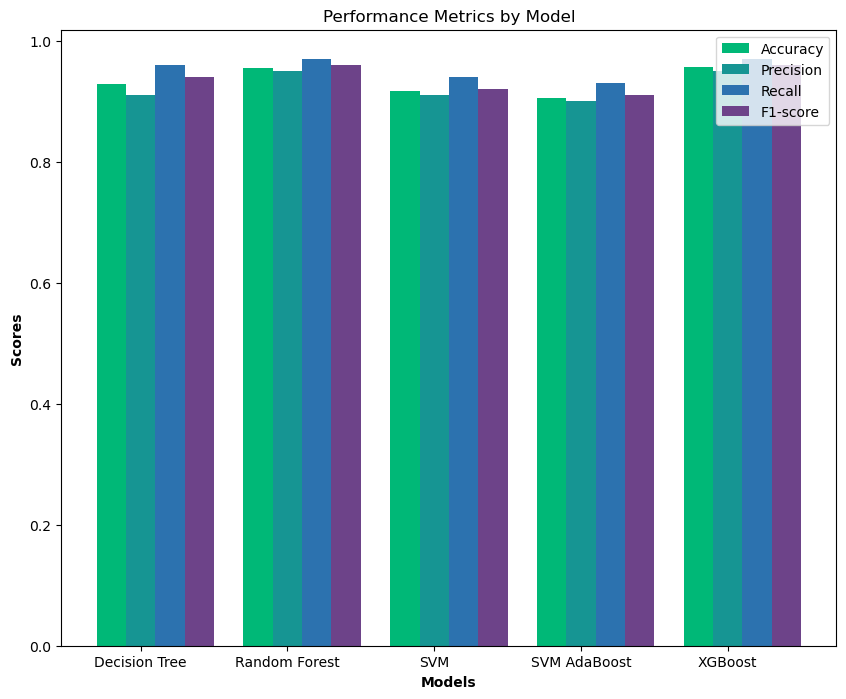

In [83]:
#Model performance comparison after applying SMOTE
models = ['Decision Tree', 'Random Forest', 'SVM', 'SVM AdaBoost', 'XGBoost']

# Define the accuracy scores
accuracy_scores = [0.928, 0.9548, 0.917, 0.906, 0.9565]

# Define the precision scores
precision_scores = [0.91, 0.95, 0.91, 0.90, 0.95]

# Define the recall scores
recall_scores = [0.96, 0.97, 0.94, 0.93, 0.97]

# Define the F1 scores
f1_scores = [0.94, 0.96, 0.92, 0.91, 0.96]

# Set the bar width
bar_width = 0.2

# Set the positions of the bars on the x-axis
r6 = np.arange(len(accuracy_scores))
r7 = [x + bar_width for x in r6]
r8 = [x + bar_width for x in r7]
r9 = [x + bar_width for x in r8]
r10 = [x + bar_width for x in r9]

# Create the bar plot
plt.figure(figsize=(10, 8))
plt.bar(r6, accuracy_scores, color='#00B877', width=bar_width, label='Accuracy')
plt.bar(r7, precision_scores, color='#169593', width=bar_width, label='Precision')
plt.bar(r8, recall_scores, color='#2C72AF', width=bar_width, label='Recall')
plt.bar(r9, f1_scores, color='#6D4389', width=bar_width, label='F1-score')

# Add some text for labels, title, and axes ticks
plt.xlabel('Models', fontweight='bold')
plt.ylabel('Scores', fontweight='bold')
plt.title('Performance Metrics by Model')
plt.xticks([r + bar_width for r in range(len(accuracy_scores))], models)
plt.legend()

# Show the plot
plt.show()
